## Draw the Manta with its shadow

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:70% !important; }</style>"))

In [2]:
from PIL import Image
def get_surface_snippet(level=1, x_offset=600, y_offset = 0, width=1000, height = 200):
    img = Image.open(f"surfaces_raw/{level}.png")
    img = img.crop((x_offset, y_offset, x_offset + width, y_offset + height))
    img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    return img

def make_shadow(img, color=(0x4a, 0x4a, 0x4a, 255)):
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] == 0:
            new_image.append(item)
        else:
            new_image.append(color)
    # update image data
    img.putdata(new_image)
    return img

resize = lambda img: img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
add_offset = lambda a,b : [sum(x) for x in zip(a,b)]


In [3]:
!mkdir shadow

mkdir: cannot create directory ‘shadow’: File exists


In [4]:
from PIL import Image

img = Image.open("manta_spin_diagrams/MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
manta = img.copy()
shadow = make_shadow(img)

In [5]:
img = Image.new( 'RGBA', (90,65))
manta_pos = (5,5)
shadow_offset = (30,15)
img.paste(shadow, (add_offset(manta_pos, shadow_offset)), mask=shadow)
img.paste(manta, manta_pos, mask=manta)
#resize(img)
img.save("shadow/shadow.png")

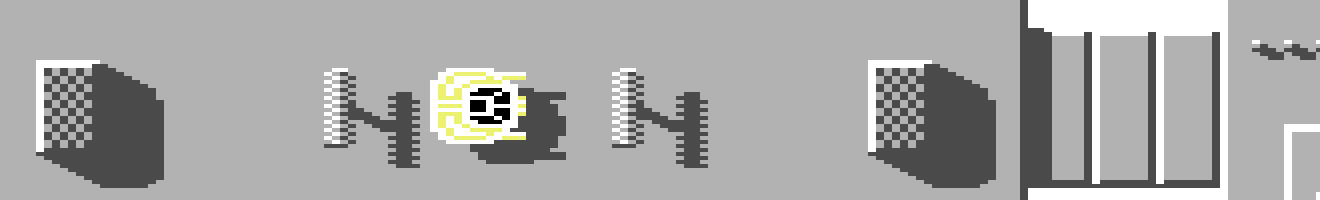

In [6]:
diagram = get_surface_snippet(level=1, x_offset=2455, y_offset = 41, width=330, height = 50)
manta_pos = (215,32)
shadow_offset = (20,10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)
img = resize(diagram)
img.save("shadow/level1.png")
img

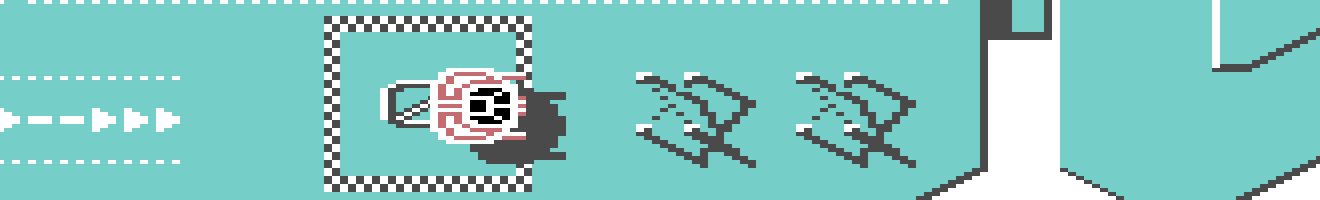

In [7]:
level = 7
diagram = get_surface_snippet(level=level, x_offset=2705, y_offset = 78, width=330, height = 50)
img = Image.open(f"manta_sprites/{level}_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
manta = img.copy()
manta_pos = (215,32)
shadow_offset = (20,10)
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.paste(manta, manta_pos, mask=manta)
img = resize(diagram)
img.save("shadow/level7.png")
img

###  Masking the shadow so that it only falls on the dreadnought surface

charset/bitmap/background bits:

- 00 (d021, black) and 01 (d022, red) are always background (sprites are always 
  in front of it)
- 10 (d023, green) and 11 (colram, blue) are foreground. it will be in front of 
  sprites with the respective priority bit set.

sprite bits:

- 00/0  (transparent) (background or sprite with lower priority)
- 10/1  (sprite color, red/blue)
- 01    (d025, yellow) (Multicolor 1)
- 11    (d026, green) (Multicolor 2)

the priority can be made up by these two rules (this order!)

- starting from sprite with lowest number, find a non transparent (0/00) color.
  if none found, background (any) shows.
- if a non transparent sprite color was found in the previous step, and the 
  priority bit of the corresponding sprite is set, 10/11 background bits will
  show in front, else the sprite color shows.

the interesting case is when eg sprite 1 and sprite 0 overlap, and sprite 0 has
the priority bit set (and sprite 1 has not). in this case 10/11 background bits
show in front of whole sprite 0.

-- https://sourceforge.net/p/vice-emu/code/HEAD/tree/testprogs/VICII/spritepriorities/

https://sta.c64.org/cbm64mem.html

In [8]:
def make_mask(i):
    img = i.copy()
    d = img.getdata()
    new_image = []
    for item in d:
        if item[3] != 0:
            new_image.append((0xff, 0xff, 0xff))
        else:
            new_image.append((0,0,0))
    # update image data
    img.putdata(new_image)
    return img


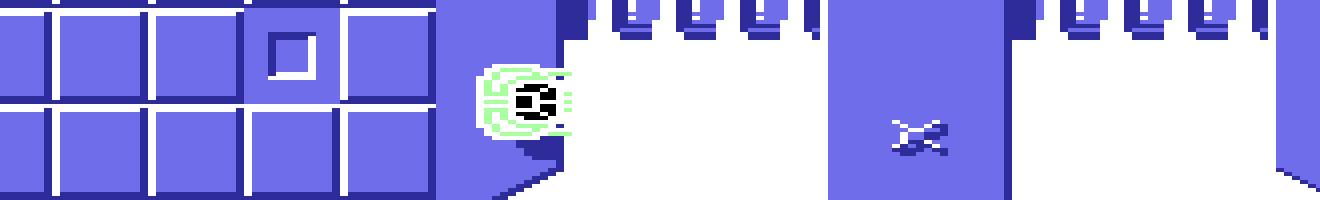

In [9]:
level = 9
diagram = get_surface_snippet(level=level, x_offset=2275, y_offset = 78, width=330, height = 50)
mask = make_mask(diagram).convert('L')
manta_pos = (238,30)
shadow_offset = (20,10)

img = Image.open(f"manta_sprites/{level}_MANTA1.png")
img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
manta = img.copy()
shadow = make_shadow(manta.copy(), color=(0x2e,0x2c,0x9b,255))
diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
diagram.putalpha(mask)
diagram.paste(manta, manta_pos, mask=manta)
img = resize(diagram)
img.save("shadow/level9_clipped.png")
img

### Do the landing loop

In [10]:
from PIL import ImageDraw, ImageFont

def generateLandingDiagram():
    image_width = 1100
    image_height = 320
    img = Image.new('RGBA', (image_width,image_height))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"TRI-ALLOY/LANDING/SEQUENCE"
    label_fnt_size = 34
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    img.paste(txt, (5,5))

    # Main Sprite image
    #character_image = character_image.resize((character_image.width * 2, character_image.height * 2), Image.NEAREST)

    x = 10
    for i in range(19,13,-1):
        limg = Image.open(f"shadow/landing_{i}.png")
        img.paste(limg, (x,40))
        x += limg.width

    x = 10
    for i in range(13,7,-1):
        limg = Image.open(f"shadow/landing_{i}.png")
        img.paste(limg, (x,170))
        x += limg.width

    return img

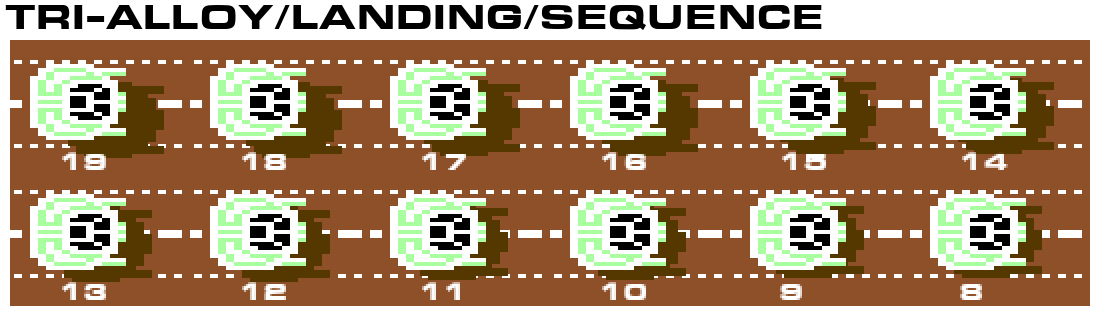

In [11]:
def textLabel(label_text, label_fnt_size = 40):
    # Sprite label
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = (len(label_text) * label_fnt_size)
    txt = Image.new('RGBA', (txt_width, label_fnt_size+10))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = (255,255,255,0))
    draw.text((0, 0), label_text, font=label_fnt, fill="white")
    return txt

for y in range(20,5,-1):
    level = 11
    diagram = get_surface_snippet(level=level, x_offset=2875, y_offset = 28, width=45, height = 34)
    manta_pos = (10,10)
    shadow_offset = (y,int(y/2))
    img = Image.open(f"manta_sprites/{level}_MANTA1.png")
    img = img.resize((int(img.width * 2), int(img.height * 2)), Image.NEAREST)
    manta = img.copy()
    shadow = make_shadow(manta.copy(),color=(0x55,0x38,0x00,255))
    diagram.paste(shadow, add_offset(manta_pos, shadow_offset), mask=shadow)
    diagram.paste(manta, manta_pos, mask=manta)
    label = textLabel(str(y), label_fnt_size=12)
    diagram.paste(label,(25,56),mask=label)
    img = resize(diagram)
    img.save(f"shadow/landing_{y}.png")
landing_img = generateLandingDiagram()
landing_img.save(f"shadow/landing_sequence.png")
landing_img

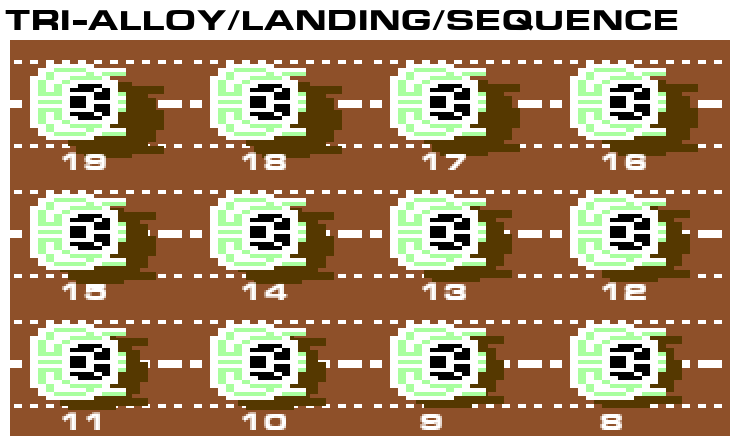

In [38]:
from PIL import ImageDraw, ImageFont

def generateLandingDiagramLarge():
    image_width = 740
    image_height = 440
    img = Image.new('RGBA', (image_width,image_height))
    draw = ImageDraw.Draw(img)
    draw.rectangle([(0,0),img.size], fill = "white")

    # Sprite label
    label_text = f"TRI-ALLOY/LANDING/SEQUENCE"
    label_fnt_size = 28
    label_fnt = ImageFont.truetype("Eurostile.ttf", label_fnt_size)
    txt_width = len(label_text) * label_fnt_size
    txt = Image.new('RGBA', (txt_width, label_fnt_size))
    draw = ImageDraw.Draw(txt)
    draw.rectangle([(0,0), txt.size], fill = "white")
    draw.text((0, 0), label_text, font=label_fnt, fill="black")
    img.paste(txt, (5,10))

    # Main Sprite image
    #character_image = character_image.resize((character_image.width * 2, character_image.height * 2), Image.NEAREST)

    x = 10
    for i in range(19,15,-1):
        limg = Image.open(f"shadow/landing_{i}.png")
        img.paste(limg, (x,40))
        x += limg.width


    x = 10
    for i in range(15,11,-1):
        limg = Image.open(f"shadow/landing_{i}.png")
        img.paste(limg, (x,170))
        x += limg.width

    x = 10
    for i in range(11,7,-1):
        limg = Image.open(f"shadow/landing_{i}.png")
        img.paste(limg, (x,300))
        x += limg.width

    return img
landing_img = generateLandingDiagramLarge()
landing_img.save(f"shadow/landing_sequence_large.png")
landing_img